# Parser Benchmark Graphs

This notebook builds meaningful visual comparisons from:

- `benchmark_results_extended.csv`
- `extraction_scores.csv`

It focuses on quality, structure, metadata extraction, and parser runtime differences.

## Metric Glossary

- `content_presence_score` (0-6): count of key content blocks found (`title`, `authors`, `doi`, `abstract`, `references`, `key_passage`).
- `meta_accuracy_score` (0-100): overall metadata correctness across title/authors/DOI/date/source/abstract/keywords.
- `structural_quality` (0-100): structure score derived from fragmentation, section-order quality, and duplicate-content penalties.
- `text_similarity` (0-1): global body-text similarity vs ground truth (after normalization and stripping references/boilerplate).
- `content_recall` (0-1): fraction of reference content recovered by the parser.
- `content_precision` (0-1): fraction of extracted content that matches reference content (noise control).
- `order_score` (0-1): preservation of sentence order relative to ground truth (includes coverage penalty).
- `parse_time_s`: total parser runtime per document in seconds.
- `time_per_page`: normalized runtime in seconds per page.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)

# Keep figures readable in notebooks
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Optional: Generate Input CSVs

Set `RUN_DATA_GENERATION = True` in the next cell to regenerate:

- `benchmark_results_extended.csv`
- `extraction_scores.csv`

Leave it `False` for normal analysis-only runs.

In [ ]:
import subprocess
from pathlib import Path

RUN_DATA_GENERATION = False
BENCHMARK_ARGS = ["--profile", "fast"]
SCORING_ARGS = ["--profile", "fast"]

if RUN_DATA_GENERATION:
    parsing_dir = Path("ingestion/parsing") if Path("ingestion/parsing").exists() else Path("..")
    print(f"Generating benchmark/scoring outputs from: {parsing_dir.resolve()}")

    # 1) Regenerate benchmark_results_extended.csv
    subprocess.run(
        ["uv", "run", "python", "benchmark.py", *BENCHMARK_ARGS],
        cwd=parsing_dir,
        check=True,
    )

    # 2) Regenerate extraction_scores.csv
    subprocess.run(
        ["uv", "run", "python", "quality_scoring.py", *SCORING_ARGS],
        cwd=parsing_dir,
        check=True,
    )

    print("Done. CSVs regenerated in ingestion/parsing/output/.")
else:
    print("Data generation skipped (RUN_DATA_GENERATION=False).")

In [2]:
from pathlib import Path

# Load files robustly whether run from repo root or notebook folder
notebook_data_dir = Path("ingestion/parsing/output")
if (notebook_data_dir / "benchmark_results_extended.csv").exists():
    base_dir = notebook_data_dir
else:
    base_dir = Path(".")

benchmark_path = base_dir / "benchmark_results_extended.csv"
extraction_path = base_dir / "extraction_scores.csv"

if not extraction_path.exists():
    raise FileNotFoundError(
        "Could not find extraction_scores.csv in "
        f"{base_dir.resolve()}"
    )

benchmark_df = pd.read_csv(benchmark_path)
quality_df = pd.read_csv(extraction_path)

print("benchmark_df shape:", benchmark_df.shape)
print("quality_df shape:", quality_df.shape)
print("Loaded from:", base_dir.resolve())
print("Using quality file:", extraction_path.name)

display(benchmark_df.head(3))
display(quality_df.head(3))

benchmark_df shape: (30, 15)
quality_df shape: (30, 40)
Loaded from: /Users/ayman/Documents/GitHub/14_EUFactForce/ingestion/parsing/output
Using quality file: extraction_scores.csv


,filename,parser_config,pages,parse_time_s,time_per_page,word_count,char_count,num_documents,has_doi,has_abstract,has_references,has_title,has_authors,metadata_score,status
0,1-s2.0-S2352250X23001574-main.pdf,pymupdf,6,0.05,0.008,4505,33607,6,found,found,found,found,found,5,success
1,1-s2.0-S2352250X23001574-main.pdf,docling_markdown,6,5.49,0.915,4636,33781,1,found,found,found,found,found,5,success
2,1-s2.0-S2352250X23001574-main.pdf,llamaparse_markdown,6,16.05,2.676,4302,34367,6,found,found,found,found,found,5,success


,filename,parser_config,doc_type,title_found,title_ratio,authors_found,authors_ratio,doi_found,abstract_found,abstract_ratio,references_found,key_passage_found,key_passage_ratio,content_presence_score,fragmentation_ratio,section_order_score,duplicate_content_ratio,structural_quality,continuity_found,continuity_total,continuity_avg_ratio,meta_title_accuracy,meta_authors_recall,meta_authors_avg_ratio,meta_doi_accuracy,meta_date_accuracy,meta_source_accuracy,meta_abstract_accuracy,meta_keyword_recall,meta_keyword_avg_ratio,meta_accuracy_score,text_similarity,content_recall,content_precision,order_score,content_ms,structural_ms,metadata_ms,similarity_ms,total_ms
0,jhab032.pdf,pymupdf,scientific_paper,found,0.875,found,1.0,found,found,1.0,found,found,0.954,6,0.0808,NaN,0.0,85.6,NaN,NaN,NaN,0.719,1.0,0.9645,1.0,1.0,1.000,1.0,1.0,1.0,94.4,0.8802,0.9325,0.9572,0.9351,216.099458,2.175125,23.988125,3383.061875,3625.362708
1,jhab032.pdf,docling_markdown,scientific_paper,found,1.000,found,1.0,not_found,found,1.0,found,found,0.938,5,0.0117,1.0,0.0,98.5,NaN,NaN,NaN,1.000,1.0,0.9285,0.0,0.0,0.605,1.0,1.0,1.0,71.0,0.8511,0.9720,0.9564,0.9772,227.291958,1.822167,26.447125,7535.077833,7790.671000
2,jhab032.pdf,llamaparse_markdown,scientific_paper,found,0.875,found,1.0,found,found,1.0,found,found,1.000,6,0.0542,1.0,0.0,93.2,NaN,NaN,NaN,0.719,1.0,1.0000,1.0,1.0,1.000,1.0,1.0,1.0,94.4,0.9737,0.9750,0.9598,0.9771,142.828458,2.033459,11.428792,1446.423208,1602.737375


In [3]:
# Merge benchmark + quality datasets on document and parser
key_cols = ["filename", "parser_config"]
merged = quality_df.merge(
    benchmark_df[[
        "filename", "parser_config", "pages", "parse_time_s", "time_per_page",
        "word_count", "char_count", "num_documents", "metadata_score", "status"
    ]],
    on=key_cols,
    how="left",
)

# Numeric cleanup for plotting
numeric_cols = [
    "quality_score",
    "structural_quality",
    "meta_accuracy_score",
    "text_similarity",
    "content_recall",
    "content_precision",
    "order_score",
    "fragmentation_ratio",
    "duplicate_content_ratio",
    "parse_time_s",
    "time_per_page",
    "num_documents",
    "pages",
    "word_count",
    "char_count",
]
for c in numeric_cols:
    if c in merged.columns:
        merged[c] = pd.to_numeric(merged[c], errors="coerce")

# content_presence_score is a 0-6 count of found content blocks, not a continuous quality metric.
# Keep backward compatibility if older files still use quality_score.
if "content_presence_score" not in merged.columns and "quality_score" in merged.columns:
    merged["content_presence_score"] = merged["quality_score"]

display(merged.head(5))

,filename,parser_config,doc_type,title_found,title_ratio,authors_found,authors_ratio,doi_found,abstract_found,abstract_ratio,references_found,key_passage_found,key_passage_ratio,content_presence_score,fragmentation_ratio,section_order_score,duplicate_content_ratio,structural_quality,continuity_found,continuity_total,continuity_avg_ratio,meta_title_accuracy,meta_authors_recall,meta_authors_avg_ratio,meta_doi_accuracy,meta_date_accuracy,meta_source_accuracy,meta_abstract_accuracy,meta_keyword_recall,meta_keyword_avg_ratio,meta_accuracy_score,text_similarity,content_recall,content_precision,order_score,content_ms,structural_ms,metadata_ms,similarity_ms,total_ms,pages,parse_time_s,time_per_page,word_count,char_count,num_documents,metadata_score,status
0,jhab032.pdf,pymupdf,scientific_paper,found,0.875,found,1.000,found,found,1.000,found,found,0.954,6,0.0808,NaN,0.0000,85.6,NaN,NaN,NaN,0.719,1.0000,0.9645,1.0,1.0,1.000,1.000,1.0,1.0,94.4,0.8802,0.9325,0.9572,0.9351,216.099458,2.175125,23.988125,3383.061875,3625.362708,20,0.04,0.002,9394,61391,20,4,success
1,jhab032.pdf,docling_markdown,scientific_paper,found,1.000,found,1.000,not_found,found,1.000,found,found,0.938,5,0.0117,1.0000,0.0000,98.5,NaN,NaN,NaN,1.000,1.0000,0.9285,0.0,0.0,0.605,1.000,1.0,1.0,71.0,0.8511,0.9720,0.9564,0.9772,227.291958,1.822167,26.447125,7535.077833,7790.671000,20,6.39,0.320,9452,61254,1,3,success
2,jhab032.pdf,llamaparse_markdown,scientific_paper,found,0.875,found,1.000,found,found,1.000,found,found,1.000,6,0.0542,1.0000,0.0000,93.2,NaN,NaN,NaN,0.719,1.0000,1.0000,1.0,1.0,1.000,1.000,1.0,1.0,94.4,0.9737,0.9750,0.9598,0.9771,142.828458,2.033459,11.428792,1446.423208,1602.737375,20,14.44,0.722,9358,60582,20,4,success
3,WHO-EURO-2025-12187-51959-79851-eng.pdf,pymupdf,institutional_report,found,1.000,found,0.707,NaN,found,0.867,found,found,0.857,5,0.1921,NaN,0.0000,65.7,NaN,NaN,NaN,1.000,0.3333,0.6003,NaN,1.0,1.000,0.867,NaN,NaN,79.6,0.7778,0.9750,0.6205,0.9777,491.917916,4.821417,260.357458,27048.747417,27805.891792,62,0.16,0.003,19877,155634,62,5,success
4,WHO-EURO-2025-12187-51959-79851-eng.pdf,docling_markdown,institutional_report,found,1.000,found,0.707,NaN,found,0.871,found,found,1.000,5,0.0482,0.7143,0.0054,84.9,NaN,NaN,NaN,1.000,0.3333,0.5913,NaN,1.0,1.000,0.871,NaN,NaN,79.6,0.8954,0.9835,0.8816,0.9878,292.872541,4.943708,295.057625,44652.349250,45245.270041,62,16.28,0.263,20884,170731,1,5,success


## 1) Parser profile heatmap (average metrics)

A compact “who is better at what” view across core quality dimensions.

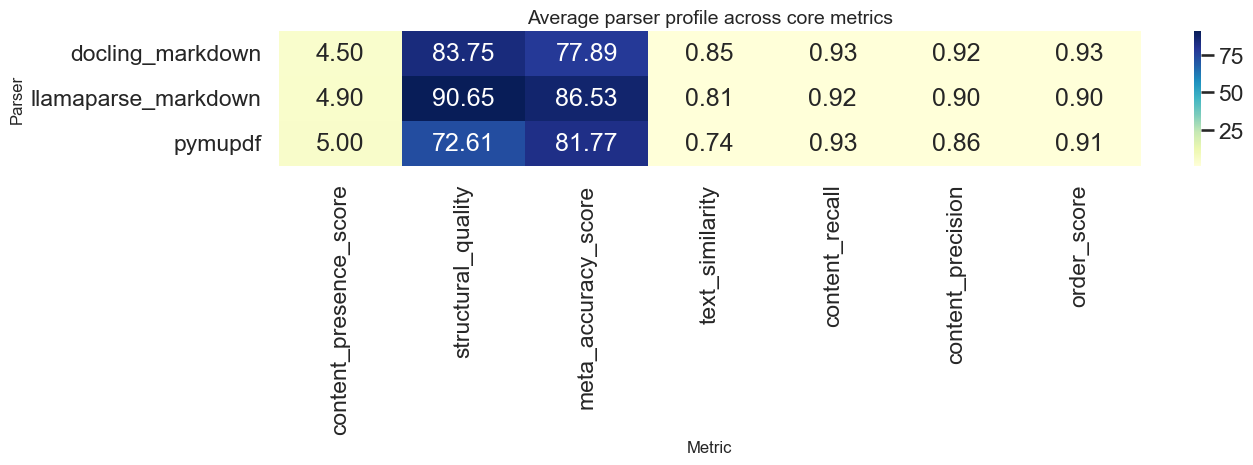

In [4]:
profile_metrics = [
    "content_presence_score",
    "structural_quality",
    "meta_accuracy_score",
    "text_similarity",
    "content_recall",
    "content_precision",
    "order_score",
]

profile = (
    merged.groupby("parser_config", dropna=False)[profile_metrics]
    .mean(numeric_only=True)
    .sort_index()
)

plt.figure(figsize=(14, 5))
sns.heatmap(profile, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average parser profile across core metrics")
plt.xlabel("Metric")
plt.ylabel("Parser")
plt.tight_layout()
plt.show()

## 2) Structure vs semantic fidelity

Checks whether better structure also means better text similarity and recall.

,doc_type,parser_config,content_presence_score,structural_quality,meta_accuracy_score,text_similarity,content_recall,order_score
0,institutional_report,docling_markdown,3.666667,81.100000,65.066667,0.779267,0.962467,0.959367
1,institutional_report,llamaparse_markdown,3.666667,85.033333,66.533333,0.825100,0.944667,0.938933
2,institutional_report,pymupdf,4.000000,66.133333,67.900000,0.767767,0.949200,0.945500
3,policy_advocacy,docling_markdown,4.000000,72.800000,93.400000,0.820400,0.762500,0.766000
4,policy_advocacy,llamaparse_markdown,4.000000,80.000000,92.500000,0.249000,0.835800,0.767000
5,policy_advocacy,pymupdf,4.000000,64.000000,90.200000,0.179300,0.757800,0.684200
6,scientific_paper,docling_markdown,5.000000,86.900000,81.716667,0.893550,0.945983,0.947833
7,scientific_paper,llamaparse_markdown,5.666667,95.233333,95.533333,0.890050,0.917217,0.910383
8,scientific_paper,pymupdf,5.666667,77.283333,87.300000,0.812283,0.941433,0.937950


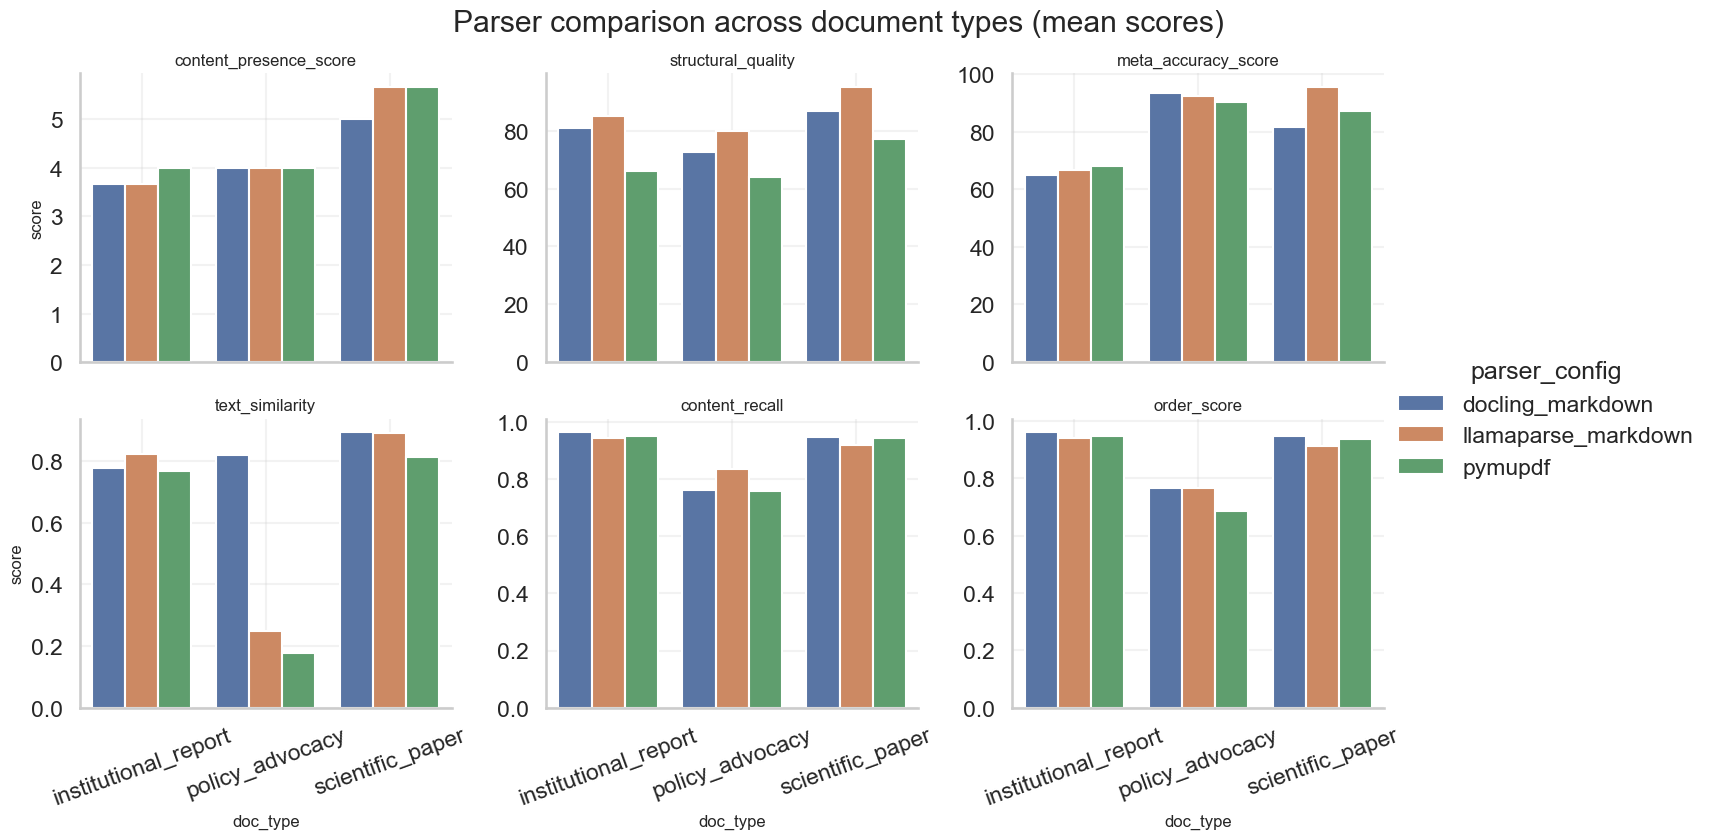

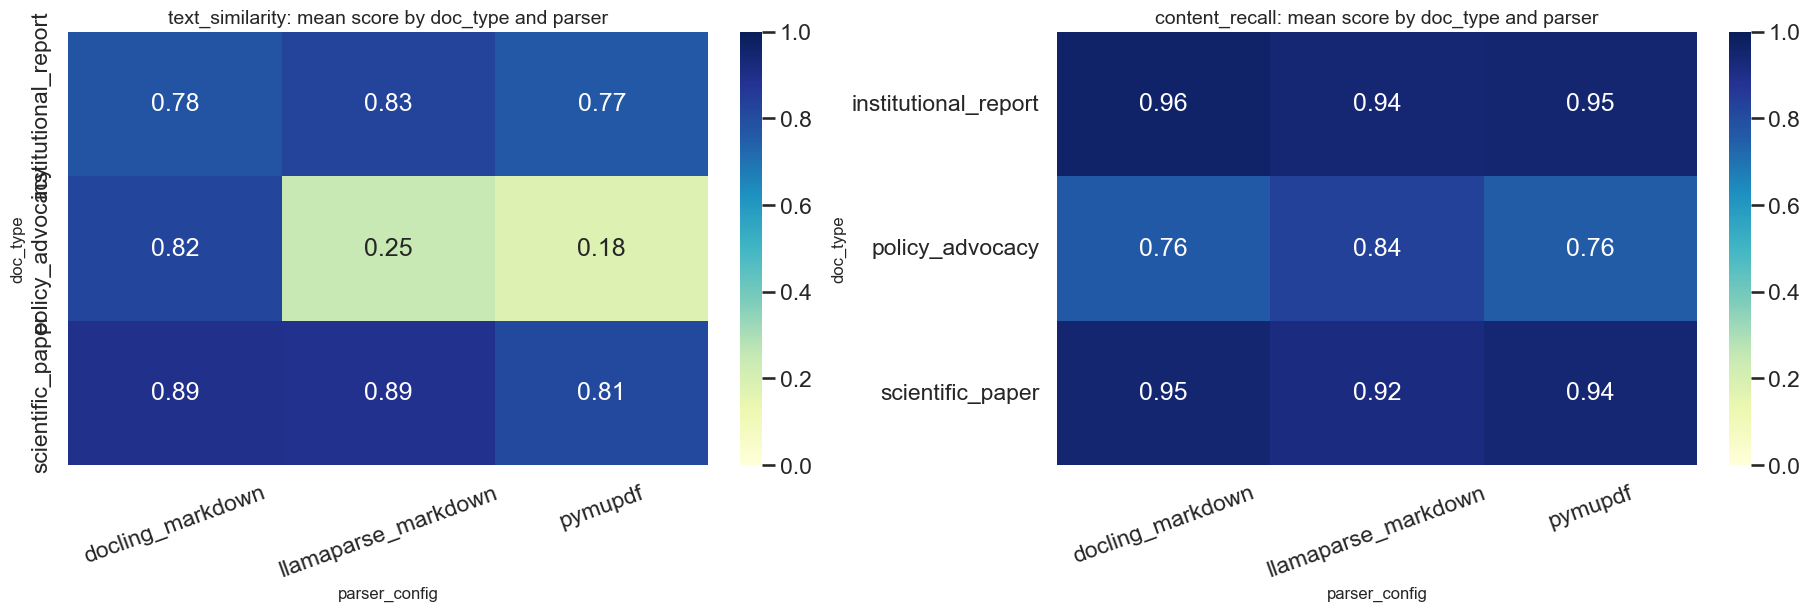

In [5]:
compare_metrics = [
    "content_presence_score",
    "structural_quality",
    "meta_accuracy_score",
    "text_similarity",
    "content_recall",
    "order_score",
]

summary = (
    merged.dropna(subset=["doc_type", "parser_config"])
    .groupby(["doc_type", "parser_config"], dropna=False)[compare_metrics]
    .mean(numeric_only=True)
    .reset_index()
)

display(summary.sort_values(["doc_type", "parser_config"]))

# Faceted bars: parser comparison inside each doc_type, per metric
long_df = summary.melt(
    id_vars=["doc_type", "parser_config"],
    value_vars=compare_metrics,
    var_name="metric",
    value_name="score",
)

g = sns.catplot(
    data=long_df,
    kind="bar",
    x="doc_type",
    y="score",
    hue="parser_config",
    col="metric",
    col_wrap=3,
    sharey=False,
    height=4,
    aspect=1.2,
)

g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)
    ax.grid(alpha=0.25)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Parser comparison across document types (mean scores)")
plt.show()

# Larger side-by-side matrices to avoid squished labels
heat_metrics = ["text_similarity", "content_recall"]
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

for ax, metric in zip(axes, heat_metrics):
    pivot = summary.pivot(index="doc_type", columns="parser_config", values=metric)
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        ax=ax,
        cbar=True,
    )
    ax.set_title(f"{metric}: mean score by doc_type and parser")
    ax.set_xlabel("parser_config")
    ax.set_ylabel("doc_type")
    ax.tick_params(axis="x", rotation=20)

plt.show()

## 3) Metadata extraction quality by parser

Shows parser differences on metadata-oriented metrics.

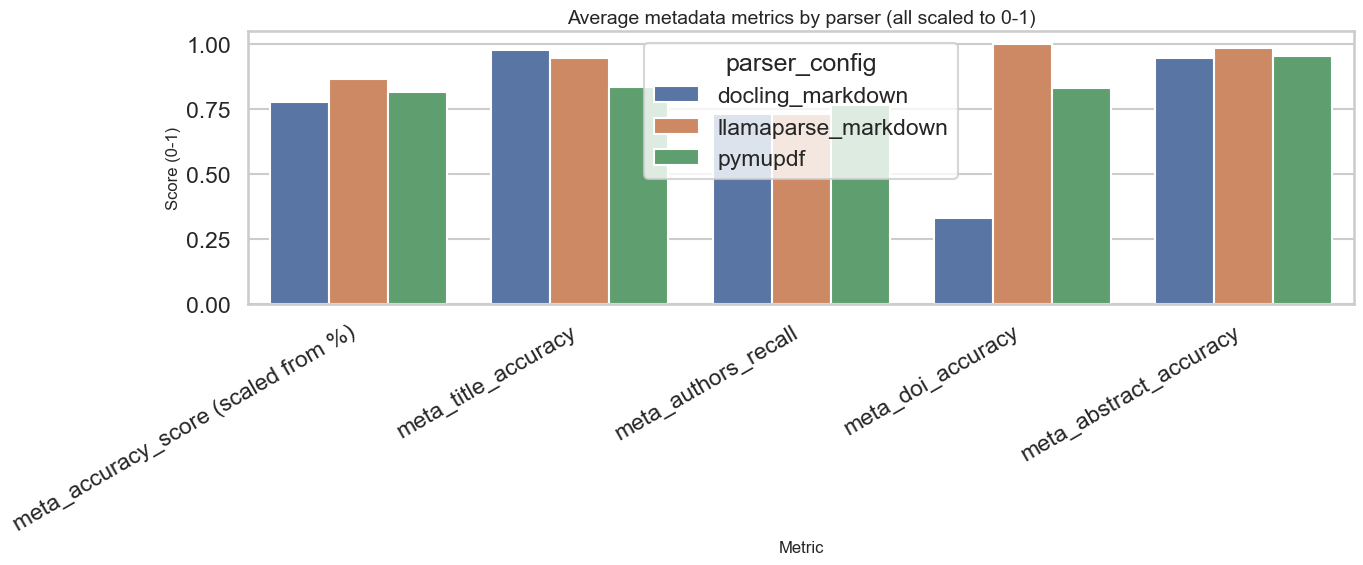

In [6]:
meta_metrics = [
    "meta_accuracy_score",
    "meta_title_accuracy",
    "meta_authors_recall",
    "meta_doi_accuracy",
    "meta_abstract_accuracy",
]

meta_long = (
    merged.groupby("parser_config", dropna=False)[meta_metrics]
    .mean(numeric_only=True)
    .reset_index()
    .melt(id_vars="parser_config", var_name="metric", value_name="value")
)

# Put all metrics on the same 0-1 scale for fair visual comparison.
# meta_accuracy_score is percentage-like (0-100), while other metrics are ratios (0-1).
meta_long["value_scaled_0_1"] = np.where(
    meta_long["metric"].eq("meta_accuracy_score"),
    meta_long["value"] / 100.0,
    meta_long["value"],
)

meta_long["metric_label"] = meta_long["metric"].replace(
    {"meta_accuracy_score": "meta_accuracy_score (scaled from %)"}
)

plt.figure(figsize=(14, 6))
sns.barplot(data=meta_long, x="metric_label", y="value_scaled_0_1", hue="parser_config")
plt.title("Average metadata metrics by parser (all scaled to 0-1)")
plt.ylim(0, 1.05)
plt.xlabel("Metric")
plt.ylabel("Score (0-1)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4) Quick winner table

Counts how often each parser wins per document on selected key metrics.

,content_presence_score,text_similarity,content_recall,content_precision,order_score
parser_config,,,,,
docling_markdown,0,3,4,6,6
llamaparse_markdown,1,5,4,4,3
pymupdf,9,2,2,0,1


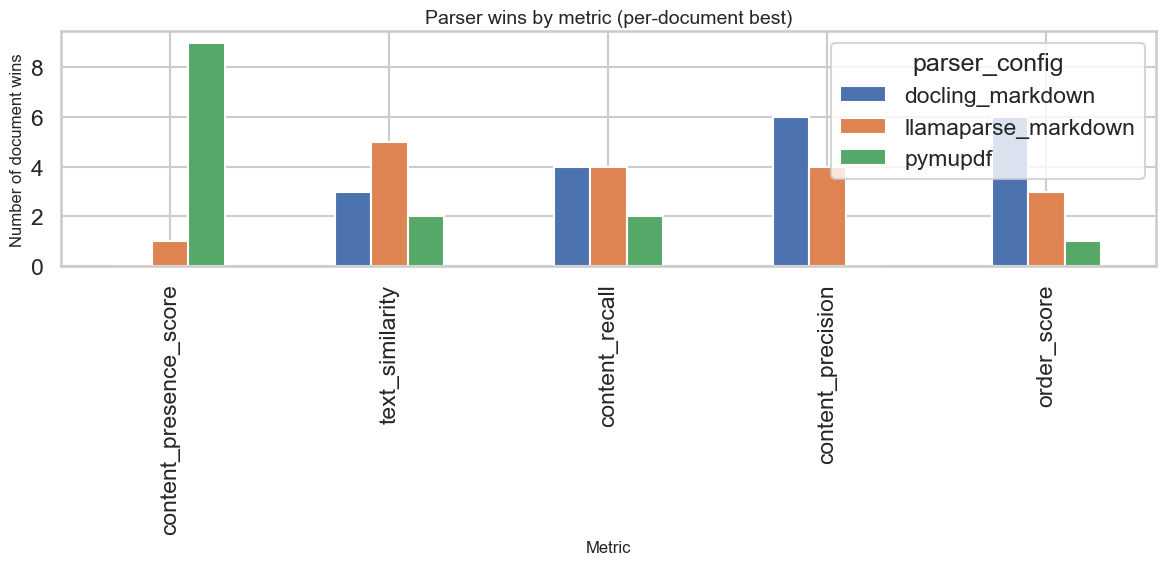

In [7]:
winner_metrics = ["content_presence_score", "text_similarity", "content_recall", "content_precision", "order_score"]

winner_counts = {}
for metric in winner_metrics:
    temp = merged[["filename", "parser_config", metric]].dropna(subset=[metric])
    if temp.empty:
        continue

    idx = temp.groupby("filename")[metric].idxmax()
    winners = temp.loc[idx, "parser_config"].value_counts()
    winner_counts[metric] = winners

winner_df = pd.DataFrame(winner_counts).fillna(0).astype(int)
display(winner_df)

if not winner_df.empty:
    winner_df.T.plot(kind="bar", figsize=(12, 6))
    plt.title("Parser wins by metric (per-document best)")
    plt.xlabel("Metric")
    plt.ylabel("Number of document wins")
    plt.tight_layout()
    plt.show()

## 5) Parser runtime comparison

Compares total parse time and normalized time per page across parsers.

,parser_config,docs,mean_parse_time_s,median_parse_time_s,mean_time_per_page,median_time_per_page
0,pymupdf,10,0.112,0.060,0.0055,0.005
1,docling_markdown,10,11.173,6.265,0.5165,0.471
2,llamaparse_markdown,10,20.663,16.110,1.2142,0.901


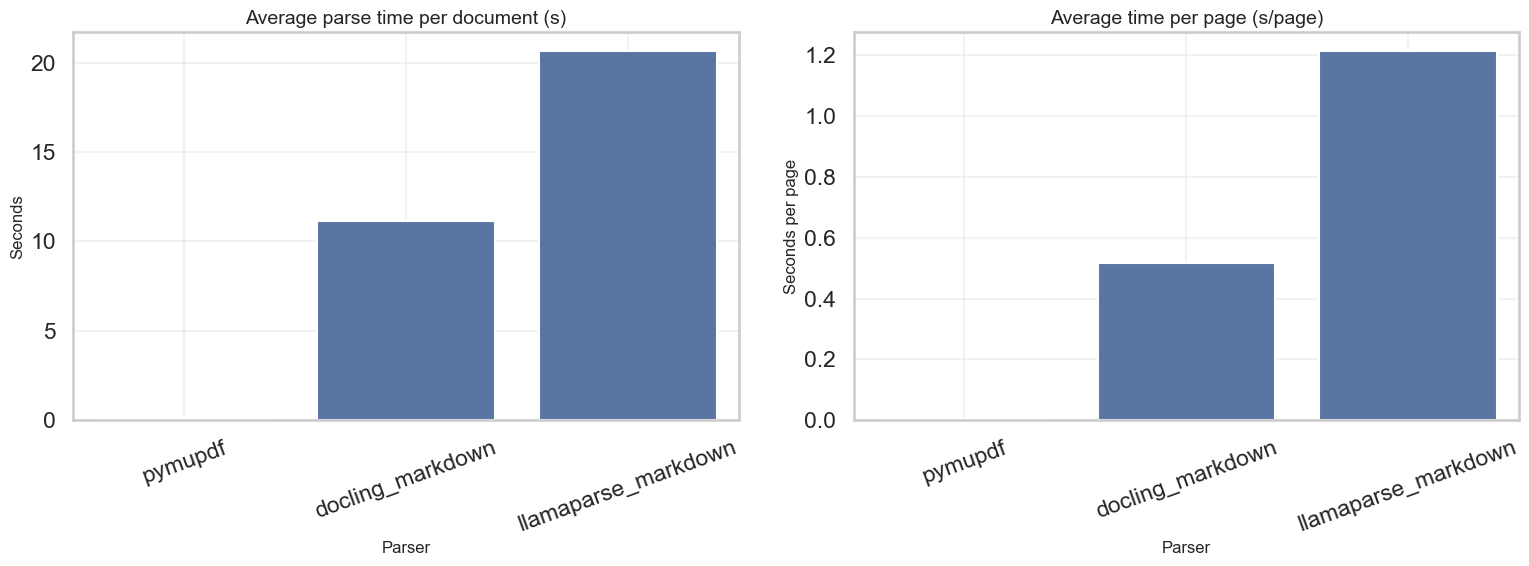

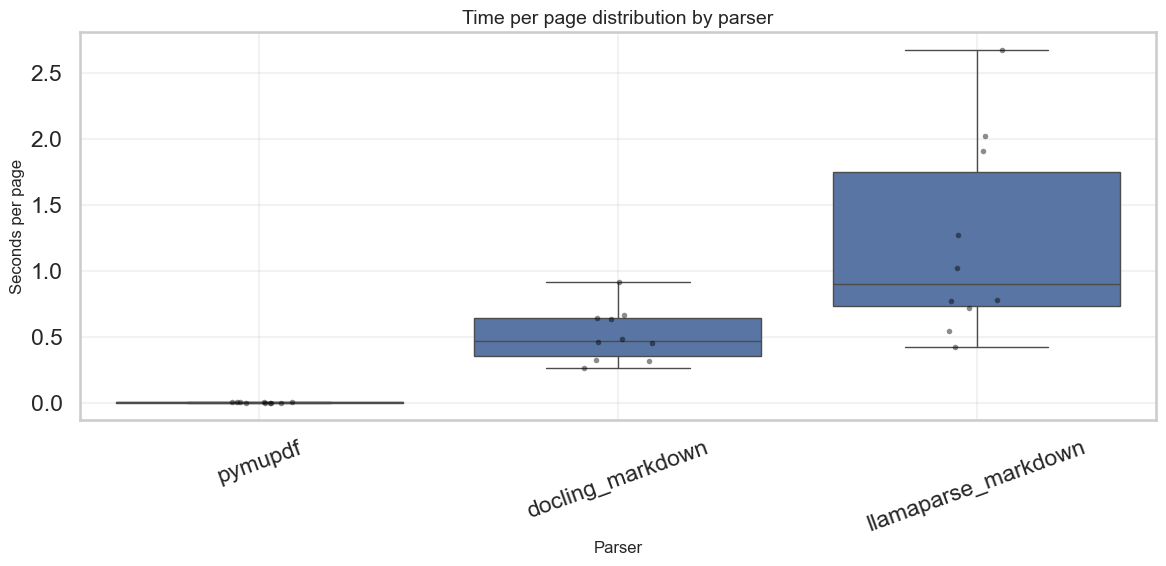

In [8]:
time_df = merged.dropna(subset=["parser_config", "parse_time_s", "time_per_page"]).copy()

if time_df.empty:
    print("No timing data available (parse_time_s / time_per_page missing).")
else:
    runtime_summary = (
        time_df.groupby("parser_config", dropna=False)
        .agg(
            docs=("filename", "count"),
            mean_parse_time_s=("parse_time_s", "mean"),
            median_parse_time_s=("parse_time_s", "median"),
            mean_time_per_page=("time_per_page", "mean"),
            median_time_per_page=("time_per_page", "median"),
        )
        .sort_values("mean_parse_time_s")
        .reset_index()
    )
    display(runtime_summary)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.barplot(
        data=runtime_summary,
        x="parser_config",
        y="mean_parse_time_s",
        ax=axes[0],
    )
    axes[0].set_title("Average parse time per document (s)")
    axes[0].set_xlabel("Parser")
    axes[0].set_ylabel("Seconds")
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].grid(alpha=0.25)

    sns.barplot(
        data=runtime_summary,
        x="parser_config",
        y="mean_time_per_page",
        ax=axes[1],
    )
    axes[1].set_title("Average time per page (s/page)")
    axes[1].set_xlabel("Parser")
    axes[1].set_ylabel("Seconds per page")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    # Distribution view to show spread/outliers
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=time_df, x="parser_config", y="time_per_page")
    sns.stripplot(
        data=time_df,
        x="parser_config",
        y="time_per_page",
        color="black",
        alpha=0.45,
        size=4,
    )
    plt.title("Time per page distribution by parser")
    plt.xlabel("Parser")
    plt.ylabel("Seconds per page")
    plt.xticks(rotation=20)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## Conclusion

Overall, `docling_markdown` provides the strongest balance on fidelity metrics (`text_similarity`, `content_recall`, `content_precision`, `order_score`), while `llamaparse_markdown` is also competitive and often strong on structural quality. `pymupdf` remains by far the fastest parser (`parse_time_s`, `time_per_page`) and can still be a pragmatic choice when throughput is the primary constraint. In practice, parser choice should be guided by our objective: maximize fidelity (`docling_markdown`) or maximize speed (`pymupdf`).